# Algoritmo Genético - Computação Inteligente

**Disciplina:** Computação Inteligente  
**Professor:** Dr. Élisson da Silva Rocha

---

## Objetivo

Implementar um Algoritmo Genético (AG) completo e parametrizável para minimizar três funções benchmark:

- **Sphere** — 30 dimensões, limites [-100, 100]
- **Rastrigin** — 30 dimensões, limites [-30, 30]
- **Rosenbrock** — 30 dimensões, limites [-5.12, 5.12]

### Componentes implementados:
- Geração aleatória da população
- Seleção proporcional ao fitness (roleta) e por torneio
- Cruzamento de 1 ponto e de 2 pontos
- Mutação com taxa ajustável
- Gráfico de convergência e Boxplot

## 1. Importações e Configurações

In [ ]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import copy


## 2. Funções Objetivo (Benchmark)

As três funções clássicas de otimização usadas para avaliar o AG.
Todas têm mínimo global conhecido, o que permite avaliar a qualidade da solução encontrada.

In [ ]:
def sphere(x):
    return sum(xi**2 for xi in x)


def rastrigin(x):
    n = len(x)
    return 10 * n + sum(xi**2 - 10 * math.cos(2 * math.pi * xi) for xi in x)


def rosenbrock(x):
    return sum(100 * (x[i+1] - x[i]**2)**2 + (x[i] - 1)**2 for i in range(len(x) - 1))

## 3. Geração da População Inicial

Cada indivíduo (cromossomo) é um vetor de valores reais gerados aleatoriamente dentro dos limites definidos.

In [ ]:
def gerar_populacao(n_populacao, n_genes, var_min, var_max):
    populacao = []
    for _ in range(n_populacao):
        cromossomo = [random.uniform(var_min, var_max) for _ in range(n_genes)]
        populacao.append(cromossomo)
    return populacao


# Teste rápido
pop_teste = gerar_populacao(5, 6, -10, 10)
for ind in pop_teste:
    print([round(g, 2) for g in ind])

[-6.81, 7.56, 7.3, -1.84, 7.81, -0.53]
[-4.39, 2.13, 4.82, -4.88, 9.65, -8.17]
[4.6, -9.46, 8.28, 4.14, -3.78, -6.56]
[-2.74, -2.9, -0.17, -9.26, -0.7, 3.97]
[-9.4, -1.32, -1.74, 0.06, 9.85, -6.12]


## 4. Avaliação (Fitness)

Cada cromossomo é avaliado pela função objetivo.  
Como estamos **minimizando**, o melhor indivíduo é aquele com **menor** valor de fitness.

In [ ]:
def avaliar_populacao(populacao, funcao_objetivo):
    populacao_avaliada = []
    for cromossomo in populacao:
        fitness = funcao_objetivo(cromossomo)
        populacao_avaliada.append((cromossomo, fitness))
    return populacao_avaliada


# Teste
pop_avaliada = avaliar_populacao(pop_teste, sphere)
for cromo, fit in pop_avaliada:
    print(f"Fitness: {fit:.2f} -> {[round(g, 2) for g in cromo]}")

Fitness: 221.46 -> [-6.81, 7.56, 7.3, -1.84, 7.81, -0.53]
Fitness: 230.78 -> [-4.39, 2.13, 4.82, -4.88, 9.65, -8.17]
Fitness: 253.76 -> [4.6, -9.46, 8.28, 4.14, -3.78, -6.56]
Fitness: 117.90 -> [-2.74, -2.9, -0.17, -9.26, -0.7, 3.97]
Fitness: 227.60 -> [-9.4, -1.32, -1.74, 0.06, 9.85, -6.12]


## 5. Métodos de Seleção

### 5.1 Seleção Proporcional ao Fitness (Roleta)
A probabilidade de seleção de cada indivíduo é proporcional ao seu fitness.  
Como estamos **minimizando**, usamos o inverso do fitness para que menores valores tenham maior probabilidade.

### 5.2 Seleção por Torneio
Seleciona `k` indivíduos aleatoriamente e escolhe o melhor dentre eles.

In [ ]:
def selecao_roleta(populacao_avaliada):
    fitness_valores = [fit for _, fit in populacao_avaliada]
    max_fitness = max(fitness_valores)

    fitness_invertido = [max_fitness - fit + 1e-6 for fit in fitness_valores]
    total_fitness = sum(fitness_invertido)

    probabilidades = [f / total_fitness for f in fitness_invertido]

    r = random.random()
    acumulado = 0
    for i, prob in enumerate(probabilidades):
        acumulado += prob
        if r <= acumulado:
            return copy.deepcopy(populacao_avaliada[i][0])

    return copy.deepcopy(populacao_avaliada[-1][0])


def selecao_torneio(populacao_avaliada, k=2):
    competidores = random.choices(populacao_avaliada, k=k)
    vencedor = min(competidores, key=lambda x: x[1])
    return copy.deepcopy(vencedor[0])


print("Seleção por Roleta:", [round(g, 2) for g in selecao_roleta(pop_avaliada)])
print("Seleção por Torneio:", [round(g, 2) for g in selecao_torneio(pop_avaliada)])

Seleção por Roleta: [-2.74, -2.9, -0.17, -9.26, -0.7, 3.97]
Seleção por Torneio: [-2.74, -2.9, -0.17, -9.26, -0.7, 3.97]


## 6. Operadores Genéticos

### 6.1 Cruzamento (Crossover)
Combina dois pais para gerar dois filhos, trocando segmentos dos cromossomos.

### 6.2 Mutação
Altera aleatoriamente genes do cromossomo com baixa probabilidade, mantendo diversidade genética.

In [ ]:
def cruzamento_1_ponto(pai1, pai2, taxa_cruzamento=0.75):
    if random.random() < taxa_cruzamento:
        ponto = random.randint(1, len(pai1) - 1)
        filho1 = pai1[:ponto] + pai2[ponto:]
        filho2 = pai2[:ponto] + pai1[ponto:]
    else:
        filho1 = copy.deepcopy(pai1)
        filho2 = copy.deepcopy(pai2)
    return filho1, filho2


def cruzamento_2_pontos(pai1, pai2, taxa_cruzamento=0.75):
    if random.random() < taxa_cruzamento:
        p1 = random.randint(1, len(pai1) - 2)
        p2 = random.randint(p1 + 1, len(pai1) - 1)
        filho1 = pai1[:p1] + pai2[p1:p2] + pai1[p2:]
        filho2 = pai2[:p1] + pai1[p1:p2] + pai2[p2:]
    else:
        filho1 = copy.deepcopy(pai1)
        filho2 = copy.deepcopy(pai2)
    return filho1, filho2


def mutacao(cromossomo, taxa_mutacao, var_min, var_max):
    for i in range(len(cromossomo)):
        if random.random() < taxa_mutacao:
            cromossomo[i] = random.uniform(var_min, var_max)
    return cromossomo


pai1 = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
pai2 = [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]

f1, f2 = cruzamento_1_ponto(pai1, pai2)
print(f"Cruzamento 1 ponto -> Filho 1: {f1}, Filho 2: {f2}")

f3, f4 = cruzamento_2_pontos(pai1, pai2)
print(f"Cruzamento 2 pontos -> Filho 1: {f3}, Filho 2: {f4}")

mutado = mutacao([1.0, 2.0, 3.0, 4.0, 5.0], taxa_mutacao=0.5, var_min=-10, var_max=10)
print(f"Após mutação: {[round(g, 2) for g in mutado]}")

Cruzamento 1 ponto -> Filho 1: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0], Filho 2: [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
Cruzamento 2 pontos -> Filho 1: [1.0, 2.0, 3.0, 4.0, 50.0, 6.0], Filho 2: [10.0, 20.0, 30.0, 40.0, 5.0, 60.0]
Após mutação: [1.0, -1.23, 9.47, -3.33, 5.0]


## 7. Algoritmo Genético Completo

Junta todas as etapas do fluxograma:
1. Gerar população inicial
2. Avaliar cada indivíduo
3. Selecionar os mais aptos
4. Aplicar cruzamento e mutação
5. Formar nova população
6. Repetir até o critério de parada

In [ ]:
def algoritmo_genetico(
    funcao_objetivo,
    n_genes=30,
    var_min=-100,
    var_max=100,
    n_populacao=30,
    n_geracoes=20,
    taxa_cruzamento=0.75,
    taxa_mutacao=0.01,
    tipo_selecao="torneio",
    tipo_cruzamento="1_ponto",
    k_torneio=2,
    elitismo=True
):
    populacao = gerar_populacao(n_populacao, n_genes, var_min, var_max)

    historico_melhor = []
    historico_media = []

    if tipo_cruzamento == "1_ponto":
        funcao_cruzamento = cruzamento_1_ponto
    else:
        funcao_cruzamento = cruzamento_2_pontos

    if tipo_selecao == "torneio":
        funcao_selecao = lambda pop_av: selecao_torneio(pop_av, k=k_torneio)
    else:
        funcao_selecao = selecao_roleta

    for geracao in range(n_geracoes):
        populacao_avaliada = avaliar_populacao(populacao, funcao_objetivo)

        populacao_avaliada.sort(key=lambda x: x[1])

        fitness_valores = [fit for _, fit in populacao_avaliada]
        historico_melhor.append(fitness_valores[0])
        historico_media.append(np.mean(fitness_valores))

        nova_populacao = []

        if elitismo:
            nova_populacao.append(copy.deepcopy(populacao_avaliada[0][0]))

        while len(nova_populacao) < n_populacao:
            pai1 = funcao_selecao(populacao_avaliada)
            pai2 = funcao_selecao(populacao_avaliada)

            filho1, filho2 = funcao_cruzamento(pai1, pai2, taxa_cruzamento)

            filho1 = mutacao(filho1, taxa_mutacao, var_min, var_max)
            filho2 = mutacao(filho2, taxa_mutacao, var_min, var_max)

            nova_populacao.append(filho1)
            if len(nova_populacao) < n_populacao:
                nova_populacao.append(filho2)

        populacao = nova_populacao

    populacao_avaliada = avaliar_populacao(populacao, funcao_objetivo)
    populacao_avaliada.sort(key=lambda x: x[1])

    melhor_solucao = populacao_avaliada[0][0]
    melhor_fitness = populacao_avaliada[0][1]

    return melhor_solucao, melhor_fitness, historico_melhor, historico_media

## 8. Configuração dos Problemas

Definição dos três problemas benchmark conforme especificado na aula.

In [ ]:
problemas = {
    "Sphere": {
        "funcao": sphere,
        "n_genes": 30,
        "var_min": -100,
        "var_max": 100,
        "otimo_global": 0.0
    },
    "Rastrigin": {
        "funcao": rastrigin,
        "n_genes": 30,
        "var_min": -30,
        "var_max": 30,
        "otimo_global": 0.0
    },
    "Rosenbrock": {
        "funcao": rosenbrock,
        "n_genes": 30,
        "var_min": -5.12,
        "var_max": 5.12,
        "otimo_global": 0.0
    }
}

N_POPULACAO = 30
N_GERACOES = 20
TAXA_CRUZAMENTO = 0.75
TAXA_MUTACAO = 0.01
N_EXECUCOES = 30

print("Parâmetros configurados:")
print(f"  População: {N_POPULACAO}")
print(f"  Gerações: {N_GERACOES}")
print(f"  Taxa de Cruzamento: {TAXA_CRUZAMENTO}")
print(f"  Taxa de Mutação: {TAXA_MUTACAO}")
print(f"  Execuções independentes: {N_EXECUCOES}")

Parâmetros configurados:
  População: 30
  Gerações: 20
  Taxa de Cruzamento: 0.75
  Taxa de Mutação: 0.01
  Execuções independentes: 30


## 9. Execução do AG — Seleção por Torneio + Cruzamento 1 Ponto

In [ ]:
resultados_torneio_1pt = {}

for nome, config in problemas.items():
    print(f"\n{'='*60}")
    print(f"Problema: {nome} | Seleção: Torneio | Cruzamento: 1 ponto")
    print(f"{'='*60}")

    todos_fitness = []
    todos_historicos = []

    for execucao in range(N_EXECUCOES):
        melhor_sol, melhor_fit, hist_melhor, hist_media = algoritmo_genetico(
            funcao_objetivo=config["funcao"],
            n_genes=config["n_genes"],
            var_min=config["var_min"],
            var_max=config["var_max"],
            n_populacao=N_POPULACAO,
            n_geracoes=N_GERACOES,
            taxa_cruzamento=TAXA_CRUZAMENTO,
            taxa_mutacao=TAXA_MUTACAO,
            tipo_selecao="torneio",
            tipo_cruzamento="1_ponto",
            elitismo=True
        )
        todos_fitness.append(melhor_fit)
        todos_historicos.append(hist_melhor)

    resultados_torneio_1pt[nome] = {
        "fitness_finais": todos_fitness,
        "historicos": todos_historicos
    }

    print(f"  Melhor fitness:  {min(todos_fitness):.4f}")
    print(f"  Pior fitness:    {max(todos_fitness):.4f}")
    print(f"  Média fitness:   {np.mean(todos_fitness):.4f}")
    print(f"  Desvio padrão:   {np.std(todos_fitness):.4f}")
    print(f"  Ótimo global:    {config['otimo_global']}")


Problema: Sphere | Seleção: Torneio | Cruzamento: 1 ponto
  Melhor fitness:  13198.3535
  Pior fitness:    37077.7014
  Média fitness:   25610.3406
  Desvio padrão:   5112.5953
  Ótimo global:    0.0

Problema: Rastrigin | Seleção: Torneio | Cruzamento: 1 ponto
  Melhor fitness:  1709.0608
  Pior fitness:    3239.6189
  Média fitness:   2538.1846
  Desvio padrão:   335.7419
  Ótimo global:    0.0

Problema: Rosenbrock | Seleção: Torneio | Cruzamento: 1 ponto
  Melhor fitness:  24512.7326
  Pior fitness:    79610.2620
  Média fitness:   48114.9993
  Desvio padrão:   13521.4435
  Ótimo global:    0.0


## 10. Execução do AG — Seleção por Roleta + Cruzamento 2 Pontos

In [ ]:
resultados_roleta_2pt = {}

for nome, config in problemas.items():
    print(f"\n{'='*60}")
    print(f"Problema: {nome} | Seleção: Roleta | Cruzamento: 2 pontos")
    print(f"{'='*60}")

    todos_fitness = []
    todos_historicos = []

    for execucao in range(N_EXECUCOES):
        melhor_sol, melhor_fit, hist_melhor, hist_media = algoritmo_genetico(
            funcao_objetivo=config["funcao"],
            n_genes=config["n_genes"],
            var_min=config["var_min"],
            var_max=config["var_max"],
            n_populacao=N_POPULACAO,
            n_geracoes=N_GERACOES,
            taxa_cruzamento=TAXA_CRUZAMENTO,
            taxa_mutacao=TAXA_MUTACAO,
            tipo_selecao="roleta",
            tipo_cruzamento="2_pontos",
            elitismo=True
        )
        todos_fitness.append(melhor_fit)
        todos_historicos.append(hist_melhor)

    resultados_roleta_2pt[nome] = {
        "fitness_finais": todos_fitness,
        "historicos": todos_historicos
    }

    print(f"  Melhor fitness:  {min(todos_fitness):.4f}")
    print(f"  Pior fitness:    {max(todos_fitness):.4f}")
    print(f"  Média fitness:   {np.mean(todos_fitness):.4f}")
    print(f"  Desvio padrão:   {np.std(todos_fitness):.4f}")
    print(f"  Ótimo global:    {config['otimo_global']}")


Problema: Sphere | Seleção: Roleta | Cruzamento: 2 pontos
  Melhor fitness:  18921.8624
  Pior fitness:    39420.6392
  Média fitness:   26764.5974
  Desvio padrão:   4722.7916
  Ótimo global:    0.0

Problema: Rastrigin | Seleção: Roleta | Cruzamento: 2 pontos
  Melhor fitness:  1211.2143
  Pior fitness:    3678.5798
  Média fitness:   2527.8858
  Desvio padrão:   553.8550
  Ótimo global:    0.0

Problema: Rosenbrock | Seleção: Roleta | Cruzamento: 2 pontos
  Melhor fitness:  15823.9030
  Pior fitness:    103178.2516
  Média fitness:   54170.2669
  Desvio padrão:   19098.1607
  Ótimo global:    0.0


## 11. Gráficos de Convergência

Mostra a evolução do melhor fitness ao longo das gerações para cada função.

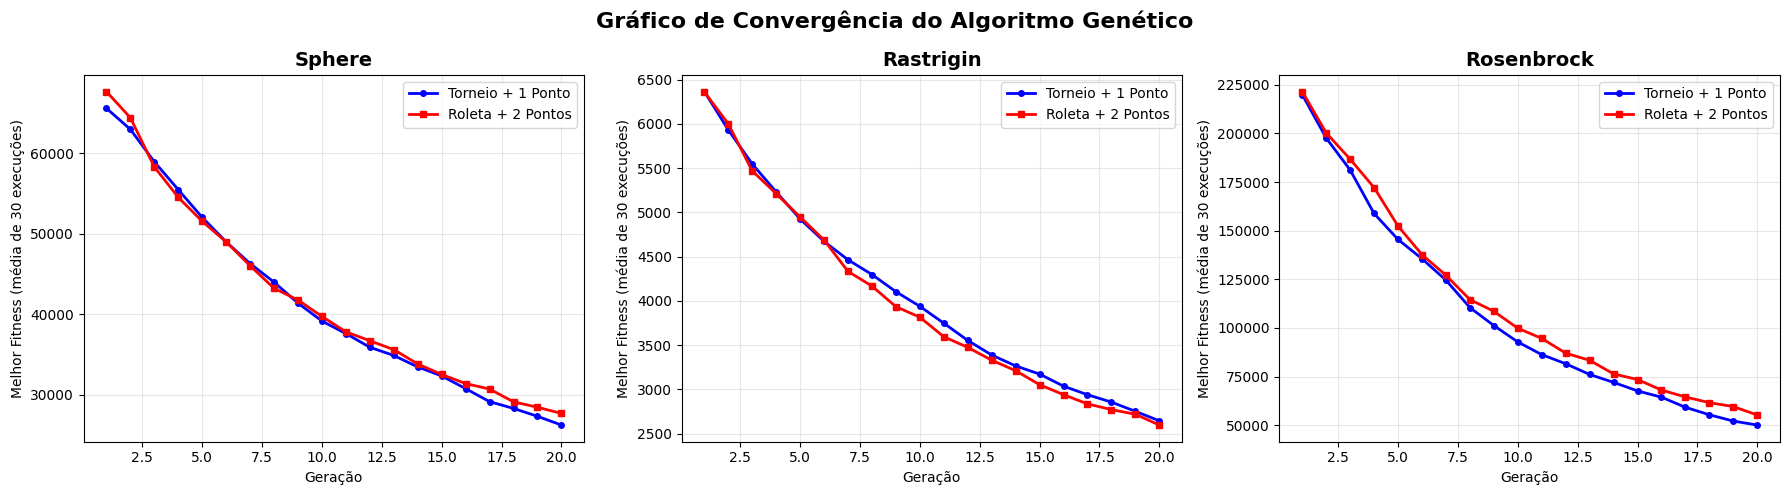

Gráfico salvo como 'convergencia.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nome in enumerate(problemas.keys()):
    ax = axes[idx]

    historicos_t = resultados_torneio_1pt[nome]["historicos"]
    media_t = np.mean(historicos_t, axis=0)
    ax.plot(range(1, N_GERACOES + 1), media_t, 'b-o', markersize=4,
            label='Torneio + 1 Ponto', linewidth=2)

    historicos_r = resultados_roleta_2pt[nome]["historicos"]
    media_r = np.mean(historicos_r, axis=0)
    ax.plot(range(1, N_GERACOES + 1), media_r, 'r-s', markersize=4,
            label='Roleta + 2 Pontos', linewidth=2)

    ax.set_title(f'{nome}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Geração')
    ax.set_ylabel('Melhor Fitness (média de 30 execuções)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Gráfico de Convergência do Algoritmo Genético', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('convergencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'convergencia.png'")

## 12. Boxplot dos Resultados

Compara a distribuição dos fitness finais obtidos nas 30 execuções independentes.

/tmp/ipykernel_10559/3149652677.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,
/tmp/ipykernel_10559/3149652677.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,
/tmp/ipykernel_10559/3149652677.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,


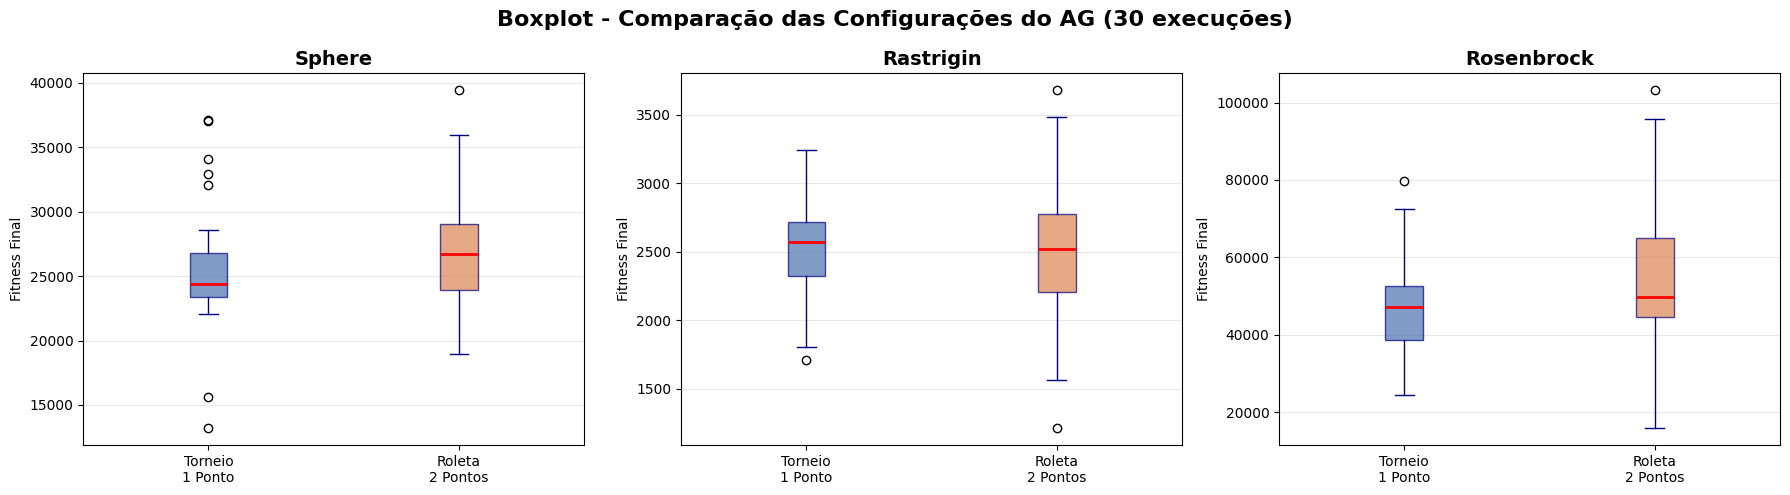

Gráfico salvo como 'boxplot.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nome in enumerate(problemas.keys()):
    ax = axes[idx]

    dados = [
        resultados_torneio_1pt[nome]["fitness_finais"],
        resultados_roleta_2pt[nome]["fitness_finais"]
    ]
    labels = ['Torneio\n1 Ponto', 'Roleta\n2 Pontos']

    bp = ax.boxplot(dados, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='navy'),
                    capprops=dict(color='navy'))

    cores = ['#4C72B0', '#DD8452']
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)

    ax.set_title(f'{nome}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Fitness Final')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Boxplot - Comparação das Configurações do AG (30 execuções)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'boxplot.png'")

## 13. Tabela Resumo dos Resultados

In [ ]:
print(f"{'='*90}")
print(f"{'TABELA RESUMO DOS RESULTADOS':^90}")
print(f"{'='*90}")
print(f"{'Função':<15} {'Configuração':<25} {'Melhor':<15} {'Média':<15} {'Desvio Pad.':<15} {'Pior':<15}")
print(f"{'-'*90}")

for nome in problemas.keys():
    fit_t = resultados_torneio_1pt[nome]["fitness_finais"]
    print(f"{nome:<15} {'Torneio + 1pt':<25} {min(fit_t):<15.4f} {np.mean(fit_t):<15.4f} {np.std(fit_t):<15.4f} {max(fit_t):<15.4f}")

    fit_r = resultados_roleta_2pt[nome]["fitness_finais"]
    print(f"{'':<15} {'Roleta + 2pts':<25} {min(fit_r):<15.4f} {np.mean(fit_r):<15.4f} {np.std(fit_r):<15.4f} {max(fit_r):<15.4f}")
    print(f"{'-'*90}")

print(f"\nNúmero de execuções independentes: {N_EXECUCOES}")
print(f"Todas as funções têm ótimo global = 0.0")

                               TABELA RESUMO DOS RESULTADOS                               
Função          Configuração              Melhor          Média           Desvio Pad.     Pior           
------------------------------------------------------------------------------------------
Sphere          Torneio + 1pt             13198.3535      25610.3406      5112.5953       37077.7014     
                Roleta + 2pts             18921.8624      26764.5974      4722.7916       39420.6392     
------------------------------------------------------------------------------------------
Rastrigin       Torneio + 1pt             1709.0608       2538.1846       335.7419        3239.6189      
                Roleta + 2pts             1211.2143       2527.8858       553.8550        3678.5798      
------------------------------------------------------------------------------------------
Rosenbrock      Torneio + 1pt             24512.7326      48114.9993      13521.4435      79610.2620     


## 14. Teste Individual (Execução Única com Detalhes)

Uma execução detalhada para visualizar o comportamento do AG.

In [ ]:
print("Execução detalhada — Sphere com Torneio + 1 Ponto")
print("=" * 60)

melhor_sol, melhor_fit, hist_melhor, hist_media = algoritmo_genetico(
    funcao_objetivo=sphere,
    n_genes=30,
    var_min=-100,
    var_max=100,
    n_populacao=30,
    n_geracoes=20,
    taxa_cruzamento=0.75,
    taxa_mutacao=0.01,
    tipo_selecao="torneio",
    tipo_cruzamento="1_ponto",
    elitismo=True
)

print(f"\nMelhor fitness encontrado: {melhor_fit:.4f}")
print(f"Ótimo global: 0.0")
print(f"\nMelhor solução (primeiros 10 genes):")
print([round(g, 4) for g in melhor_sol[:10]])

print(f"\nEvolução do melhor fitness por geração:")
for i, fit in enumerate(hist_melhor):
    barra = '#' * max(1, int(50 * (1 - fit / hist_melhor[0]))) if hist_melhor[0] > 0 else '#'
    print(f"  Geração {i+1:>2}: {fit:>12.2f}  {barra}")

Execução detalhada — Sphere com Torneio + 1 Ponto

Melhor fitness encontrado: 27578.9835
Ótimo global: 0.0

Melhor solução (primeiros 10 genes):
[-18.7348, -37.117, 16.9192, 5.8517, -69.7515, -7.5319, -1.1144, -3.0355, -26.5549, 28.4414]

Evolução do melhor fitness por geração:
  Geração  1:     68392.39  #
  Geração  2:     68392.39  #
  Geração  3:     61927.11  ####
  Geração  4:     52021.30  ###########
  Geração  5:     52021.30  ###########
  Geração  6:     51214.62  ############
  Geração  7:     46411.11  ################
  Geração  8:     44276.18  #################
  Geração  9:     43984.93  #################
  Geração 10:     42766.33  ##################
  Geração 11:     37612.00  ######################
  Geração 12:     37612.00  ######################
  Geração 13:     35438.78  ########################
  Geração 14:     35438.78  ########################
  Geração 15:     33149.42  #########################
  Geração 16:     30726.92  ###########################
  Ger